## **02. Features & Preprocessing — Conversion Rate Challenge**

**Objectif** : nettoyer les données, créer de nouvelles features, construire le pipeline de transformation et préparer les sets train/val/test.

**Plan du notebook** :
1. Chargement des données
2. Traitement des outliers (âge)
3. Feature Engineering
4. Split train/validation stratifié
5. Pipeline ColumnTransformer

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import pickle

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
conversion_data_train_path = '../data/conversion_data_train.csv'
conversion_data_test_path = '../data/conversion_data_test.csv'
output_image_path = '../outputs/images'
output_model_path = '../outputs/models'
output_data_path = '../outputs/data'
output_processed_path = '../outputs/processed'

### **1. Chargement des données**

In [3]:
df = pd.read_csv(conversion_data_train_path)
df_test_raw = pd.read_csv(conversion_data_test_path)

print(f'Train shape : {df.shape}')
print(f'Test shape  : {df_test_raw.shape}')
df.head()

Train shape : (284580, 6)
Test shape  : (31620, 5)


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


### **2. Traitement des outliers - âge**

In [4]:
print('Outliers âge > 79 ans (train) :')
print(df[df['age'] > 79]['age'].value_counts())
print()
print('Outliers âge > 79 ans (test) :')
print(df_test_raw[df_test_raw['age'] > 79]['age'].value_counts())

Outliers âge > 79 ans (train) :
age
111    1
123    1
Name: count, dtype: int64

Outliers âge > 79 ans (test) :
Series([], Name: count, dtype: int64)


In [5]:
# Correction : remplacer les âges > 79 par la médiane calculée sur les valeurs valides
# IMPORTANT : médiane calculée sur le train uniquement
age_median = df[df['age'] <= 79]['age'].median()
print(f'Médiane âge (train, sans outliers) : {age_median}')

df['age'] = df['age'].where(df['age'] <= 79, age_median)
df_test_raw['age'] = df_test_raw['age'].where(df_test_raw['age'] <= 79, age_median)

print(f'Age max après correction (train) : {df["age"].max()}')
print(f'Age max après correction (test)  : {df_test_raw["age"].max()}')

Médiane âge (train, sans outliers) : 30.0
Age max après correction (train) : 79
Age max après correction (test)  : 69


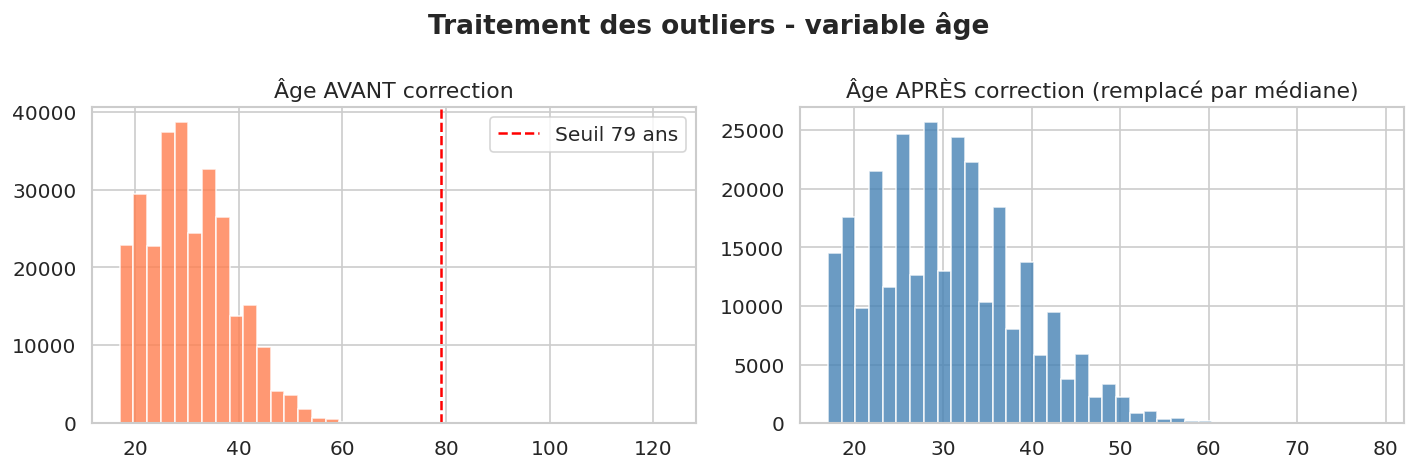

In [7]:
# Visualisation avant/après
df_orig = pd.read_csv(conversion_data_train_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_orig['age'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[0].set_title('Âge AVANT correction')
axes[0].axvline(79, color='red', linestyle='--', label='Seuil 79 ans')
axes[0].legend()

axes[1].hist(df['age'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Âge APRÈS correction (remplacé par médiane)')

plt.suptitle('Traitement des outliers - variable âge', fontweight='bold')
plt.tight_layout()
plt.show()

### **3. Feature Engineering**

Basé sur les insights EDA, on crée 3 features binaires :
- `high_engagement` : pages visitées > 10 => 45.9% de conversion (vs 0.5%)
- `is_returning` : utilisateur existant (= 1 - new_user) => lisibilité
- `is_china` : flag Chine => comportement radicalement différent (0.13% de conversion)

In [8]:
def add_features(df):
    df = df.copy()
    df['high_engagement'] = (df['total_pages_visited'] > 10).astype(int)
    df['is_returning'] = (1 - df['new_user']).astype(int)
    df['is_china'] = (df['country'] == 'China').astype(int)
    return df

df = add_features(df)
df_test_raw = add_features(df_test_raw)

print('Features disponibles :', list(df.columns))

Features disponibles : ['country', 'age', 'new_user', 'source', 'total_pages_visited', 'converted', 'high_engagement', 'is_returning', 'is_china']


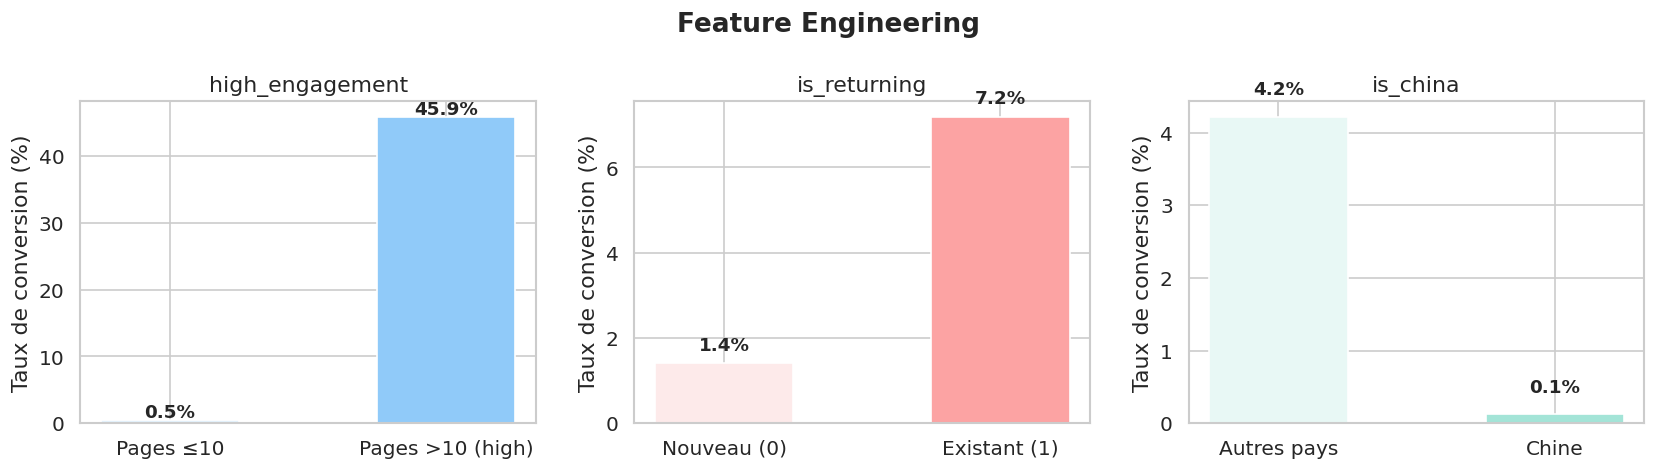

In [9]:
# Vérification 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

feats = [
    (
        'high_engagement',
        ['Pages ≤10', 'Pages >10 (high)'],
        ['#e3f2fd', '#90caf9'] 
    ),
    (
        'is_returning',
        ['Nouveau (0)', 'Existant (1)'],
        ['#fdeaea', '#fca3a3']  
    ),
    (
        'is_china',
        ['Autres pays', 'Chine'],
        ['#e8f8f5', '#a3e4d7'] 
    ),
]
for ax, (feat, xlabels, colors) in zip(axes, feats):
    rates = df.groupby(feat)['converted'].mean() * 100
    bars = ax.bar(xlabels, rates.values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'{feat}')
    ax.set_ylabel('Taux de conversion (%)')
    for bar, v in zip(bars, rates.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Feature Engineering', fontweight='bold')
plt.tight_layout()
plt.show()

### **4. Split train/validation stratifié**

In [10]:
X = df.drop('converted', axis=1)
y = df['converted']

# stratify=y pour conserver le ratio 3.23% 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'X_train : {X_train.shape} | X_val : {X_val.shape}')
print(f'Conversion rate train : {y_train.mean():.4f}')
print(f'Conversion rate val   : {y_val.mean():.4f}')
print('Stratification OK: ratio identique dans train/val')

X_train : (227664, 8) | X_val : (56916, 8)
Conversion rate train : 0.0323
Conversion rate val   : 0.0323
Stratification OK: ratio identique dans train/val


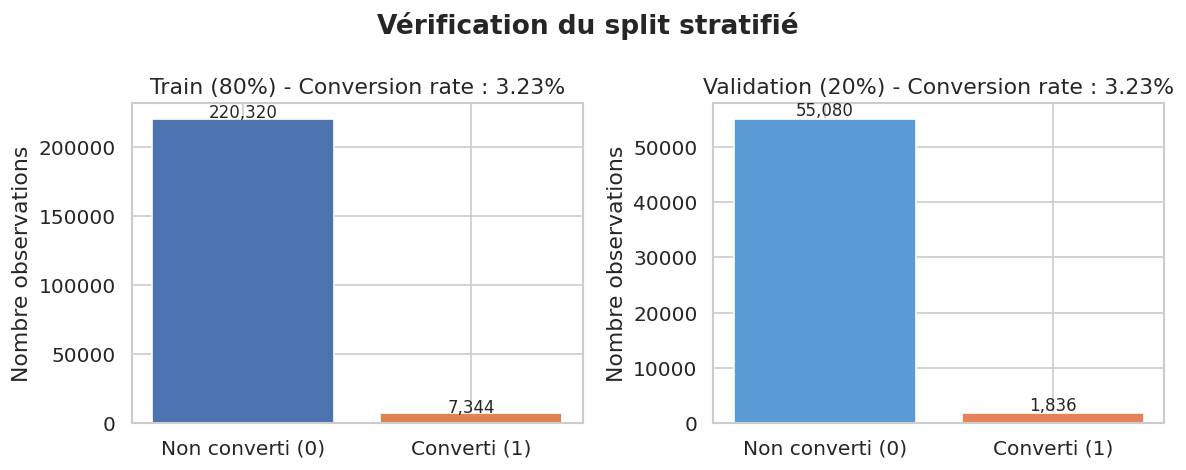

In [12]:
# Visualisation du split
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, y_s, cols) in zip(axes, [
    ('Train (80%)', y_train, ['#4C72B0','#DD8452']),
    ('Validation (20%)', y_val, ['#5b9bd5','#e8815a'])
]):
    counts = y_s.value_counts()
    bars = ax.bar(['Non converti (0)', 'Converti (1)'], counts.values, color=cols, edgecolor='white')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+500, f'{v:,}', ha='center', fontsize=10)
    ax.set_title(f'{name} - Conversion rate : {y_s.mean()*100:.2f}%')
    ax.set_ylabel('Nombre observations')

plt.suptitle('Vérification du split stratifié', fontweight='bold')
plt.tight_layout()
plt.show()

### **5. Pipeline ColumnTransformer**

In [13]:
num_features = ['age', 'total_pages_visited']
cat_features = ['country', 'source']
bin_features = ['new_user', 'high_engagement', 'is_returning', 'is_china']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features),
    ('bin', 'passthrough', bin_features),
], remainder='drop')

# Fit UNIQUEMENT sur X_train 
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(df_test_raw)

feature_names = num_features + cat_features + bin_features
print(f'Feature names : {feature_names}')
print(f'X_train_proc : {X_train_proc.shape}')
print(f'X_val_proc   : {X_val_proc.shape}')
print(f'X_test_proc  : {X_test_proc.shape}')

Feature names : ['age', 'total_pages_visited', 'country', 'source', 'new_user', 'high_engagement', 'is_returning', 'is_china']
X_train_proc : (227664, 8)
X_val_proc   : (56916, 8)
X_test_proc  : (31620, 8)


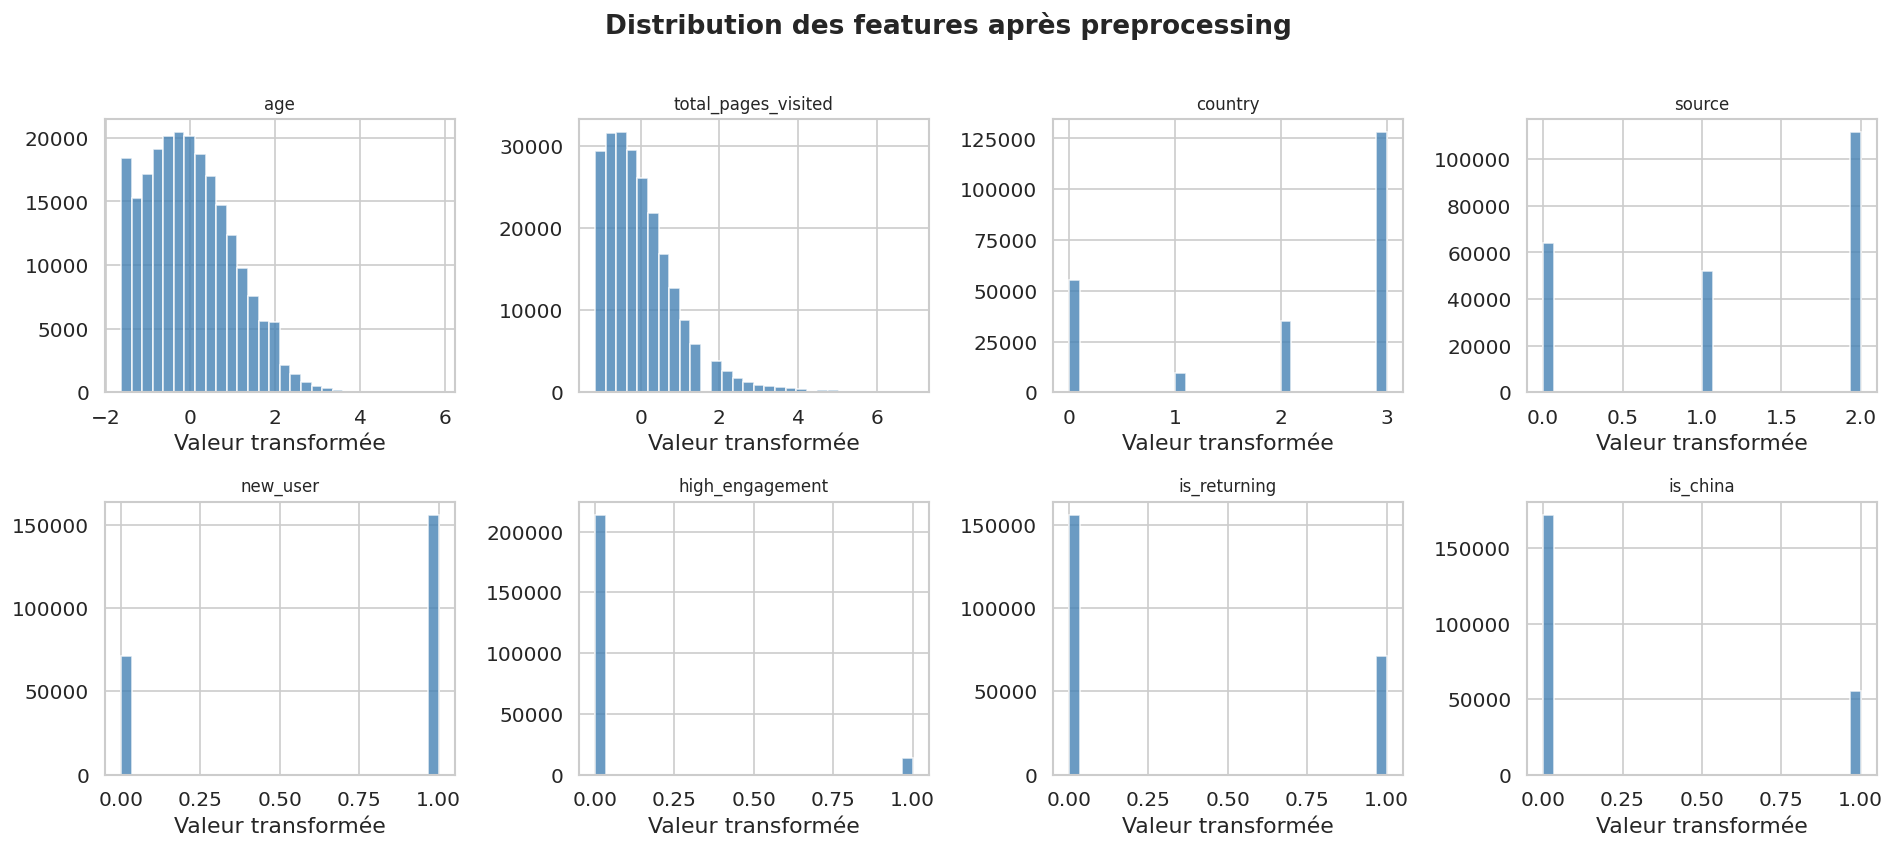

In [14]:
# Distribution des features après preprocessing
X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col, ax in zip(feature_names, axes.flat):
    ax.hist(X_train_df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Valeur transformée')

plt.suptitle('Distribution des features après preprocessing', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### **6. Sauvegarde des outputs**

In [16]:
# Preprocessor
with open(f'{output_model_path}/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Sets transformés
np.save(f'{output_processed_path}/X_train.npy', X_train_proc)
np.save(f'{output_processed_path}/X_val.npy',   X_val_proc)
np.save(f'{output_processed_path}/X_test.npy',  X_test_proc)
y_train.to_csv(f'{output_processed_path}/y_train.csv', index=False)
y_val.to_csv(f'{output_processed_path}/y_val.csv',     index=False)

print(f'{output_model_path}/preprocessor.pkl')
print(f'{output_processed_path}/X_train.npy :', X_train_proc.shape)
print(f'{output_processed_path}/X_val.npy :', X_val_proc.shape)
print(f'{output_processed_path}/X_test.npy :', X_test_proc.shape)
print(f'{output_processed_path}/y_train.csv :', y_train.shape)
print(f'{output_processed_path}/y_val.csv :', y_val.shape)

../outputs/models/preprocessor.pkl
../outputs/processed/X_train.npy : (227664, 8)
../outputs/processed/X_val.npy : (56916, 8)
../outputs/processed/X_test.npy : (31620, 8)
../outputs/processed/y_train.csv : (227664,)
../outputs/processed/y_val.csv : (56916,)
